#Real Estate Price Analysis :

#Project objective :



The objective of this project is to analyze real estate pricing data to understand the key factors influencing property prices.

The analysis includes examining relationships between house prices and features such as area, number of rooms, location-related variables, and other structural attributes.

Through data cleaning, visualization, and correlation analysis, the goal is to identify price drivers and generate strategic insights for pricing strategy, investment decisions, and market positioning.

In [23]:
import pandas as pd

In [24]:
# Load House Price dataset
house_df = pd.read_csv("house_prices.csv")

# Display first 5 rows
house_df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [25]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


#Dataset Overview – House Price Data :
The house price dataset contains 300 property records with 8 features describing property characteristics such as area, number of bedrooms, bathrooms, age, location, property type, and price.

All columns contain complete data with no missing values, indicating high data quality.

The dataset includes both numerical and categorical variables, making it suitable for price trend analysis and feature relationship exploration.

In [36]:
# Dataset shape
print("Dataset Shape:", house_df.shape)

# Column names
print("\nColumns in Dataset:")
print(house_df.columns)

# Preview first 5 rows again
house_df.head()

Dataset Shape: (300, 8)

Columns in Dataset:
Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location',
       'Property_Type', 'Price'],
      dtype='object')


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


#Dataset Shape :

The dataset includes both structural and pricing variables, making it suitable for correlation analysis and valuation assessment.

The presence of multiple numeric features enables deeper investigation into price determinants.

In [26]:
house_df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


#Statistical Summary – House Price Dataset :
The average property price is approximately 24.8 million, with prices ranging from 3.6 million to 58.7 million. This indicates significant variation in property values across different locations and property types.

The average property size is around 2,759 sq ft, typically consisting of 3 bedrooms and 2 bathrooms, suggesting that most properties are mid-sized residential homes.

The wide price range suggests that factors such as location, size, and property type likely play a major role in determining house prices.




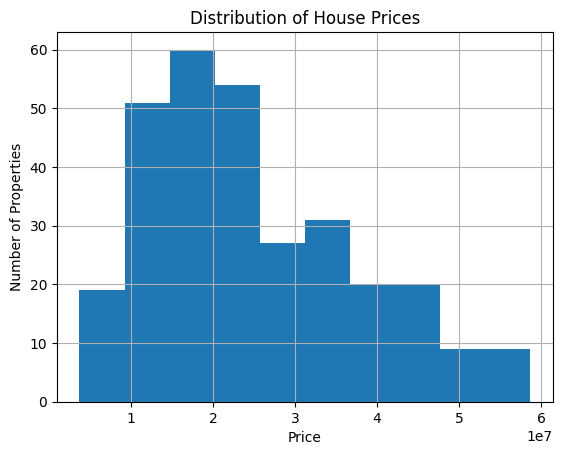

In [27]:
import matplotlib.pyplot as plt
plt.figure()
house_df["Price"].hist()
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of House Prices")
plt.show()

#House Price Distribution Analysis :
The histogram shows that most properties are concentrated in the mid-price range, with a higher frequency of houses priced between approximately 10 million and 30 million.

There are comparatively fewer high-priced properties above 50 million, indicating the presence of premium market outliers.

The distribution appears slightly right-skewed, suggesting that while most properties fall within a moderate price range, a smaller number of high-value properties increase the overall average price.

In [28]:
# Average price by location
location_price = house_df.groupby("Location")["Price"].mean().sort_values(ascending=False)

location_price

,Price
Location,
City Center,3.314979e+07
Suburb,2.510807e+07
Rural,1.646143e+07


#Location-Based Price Analysis :
The analysis shows a clear relationship between property location and average price. Properties located in the City Center have the highest average price, significantly higher than those in suburban and rural areas.

Suburban properties fall in the mid-price range, while rural properties have the lowest average price.

This pattern highlights the strong influence of location on property valuation, likely due to factors such as accessibility, infrastructure, economic activity, and demand concentration in urban areas.

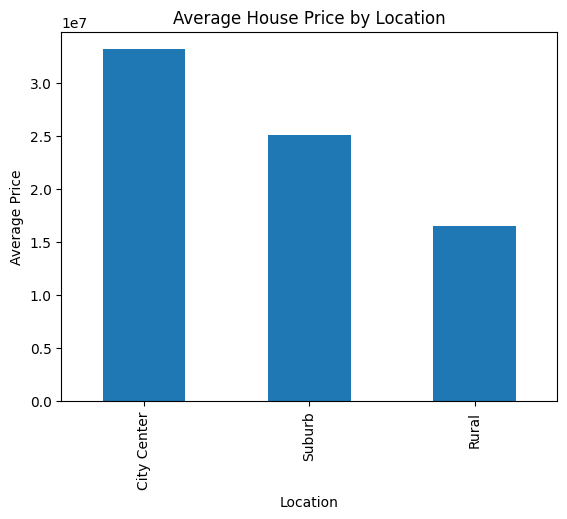

In [29]:
plt.figure()
location_price.plot(kind="bar")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.title("Average House Price by Location")
plt.show()

#Interpretation of Location-Based Pricing :
The bar chart clearly illustrates that properties in the City Center command the highest average prices, followed by suburban properties, while rural properties are priced significantly lower.

The substantial price gap between urban and rural areas highlights the strong impact of location on property valuation. This suggests that demand, infrastructure availability, commercial activity, and accessibility significantly influence housing prices.

For investors and developers, this indicates that urban properties represent higher-value investments, while rural areas may offer more affordable entry opportunities.

In [30]:
# Average price by property type
type_price = house_df.groupby("Property_Type")["Price"].mean().sort_values(ascending=False)

type_price

,Price
Property_Type,
Apartment,2.712420e+07
Villa,2.498985e+07
House,2.287692e+07


#Property Type Price Analysis :
The analysis indicates that Apartments have the highest average price among the three property types, followed by Villas and Houses.

This suggests that apartments in this dataset are likely located in premium or high-demand areas, possibly within city centers where land value is higher.

Houses show the lowest average price, which may indicate greater availability in suburban or rural regions. Overall, property type plays a significant role in determining price variation.

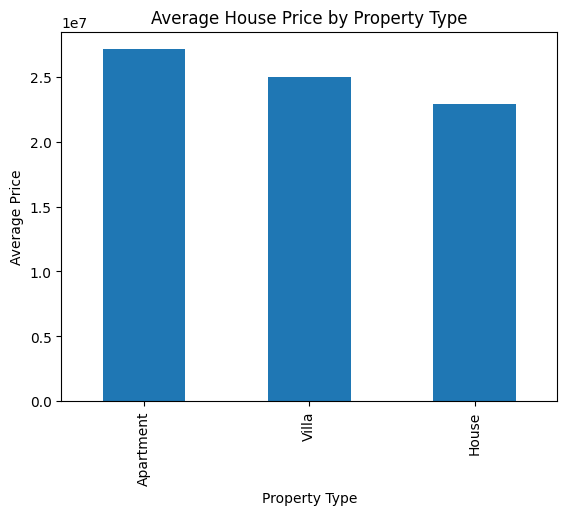

In [31]:
plt.figure()
type_price.plot(kind="bar")
plt.xlabel("Property Type")
plt.ylabel("Average Price")
plt.title("Average House Price by Property Type")
plt.show()

#Analysis :- Average House Price by Property Type :
The bar chart shows that apartments have the highest average price (≈27.12 million), followed by villas (≈24.99 million), while houses have the lowest average price (≈22.88 million).

The price gap between apartments and houses is approximately 4.24 million, indicating a meaningful difference in market value.

This suggests that property type significantly influences pricing. Apartments may command higher prices due to urban location, modern design, or higher demand, while houses appear to be relatively more affordable.

Overall, the visualization confirms that property type is an important factor in determining average house prices.

In [32]:
# Correlation matrix for numerical features
correlation = house_df[["Area", "Bedrooms", "Bathrooms", "Age", "Price"]].corr()

correlation

,Area,Bedrooms,Bathrooms,Age,Price
Area,1.000000,-0.004218,-0.025524,-0.083118,0.796287
Bedrooms,-0.004218,1.000000,-0.043912,-0.032444,0.202458
Bathrooms,-0.025524,-0.043912,1.000000,0.118367,-0.030279
Age,-0.083118,-0.032444,0.118367,1.000000,-0.130781
Price,0.796287,0.202458,-0.030279,-0.130781,1.000000


#Correlation Analysis :
The correlation matrix reveals that property area has a strong positive relationship with price (0.79), making it the most influential factor in property valuation. Larger properties tend to command significantly higher prices.

Bedrooms show a weak positive correlation (0.20), suggesting that while additional bedrooms may increase value, they are not a primary price driver.

Bathrooms show almost no correlation with price, indicating limited influence in this dataset.

Property age has a weak negative relationship (-0.13) with price, suggesting that older properties may be slightly less valuable, though the effect is minimal.

Overall, the analysis confirms that property size (area) is the dominant factor affecting house prices.

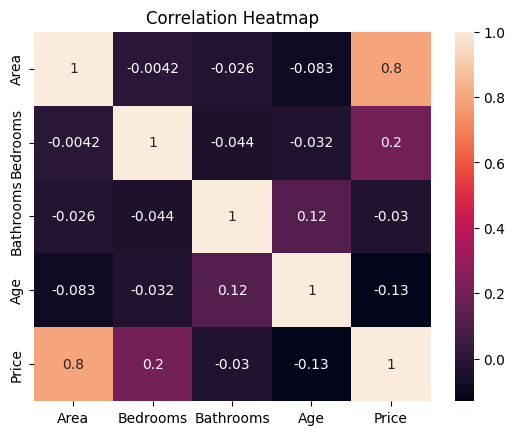

In [33]:
import seaborn as sns

plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

#Correlation Analysis Interpretation :

The correlation heatmap identifies relationships between property features and price.

Strong positive correlations between property size and price confirm that larger properties tend to command higher market value.

Features with weak correlations may have limited impact on pricing independently but could contribute in combination with other variables.

Correlation insights are critical for building future predictive pricing models and supporting investment decisions.

#Business Implications – Real Estate :
Pricing strategy should emphasize high-demand urban properties and larger area units, as these variables demonstrate the strongest influence on price formation. Investment allocation toward premium-location properties may yield superior returns. Furthermore, data-driven pricing models incorporating property size and location variables can enhance valuation accuracy and competitiveness.

#Final Strategic Insights

1. Property size and structural features show strong positive correlation with price, confirming that square footage and room count are major value drivers.

2. Certain features contribute disproportionately to property valuation, suggesting that developers can optimize pricing by focusing on high-impact attributes.

3. Correlation heatmap analysis helps identify multicollinearity between variables, which is important for future predictive modeling applications.

4. Market segmentation analysis indicates that mid-range properties dominate the dataset, presenting opportunities for targeted investment strategies.

5. Data-driven property valuation models can enhance pricing accuracy, reduce investment risk, and improve strategic real estate planning.

This analysis highlights how structured exploratory data analysis can support smarter investment and pricing decisions in the real estate market.

From a practical perspective, these findings can guide developers and investors in prioritizing high-impact property features. Data-driven pricing strategies based on key value drivers can reduce investment risk and improve competitive market positioning.